# §6 Monte Carlo on combined ML#2

IID bootstrap (10,000 sims) on the ML#2-filtered portfolio trade stream.
Same plot set as §3.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=None)
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 11,851


Loaded combos_ml2 from cache (10 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 5, 'pct5_compound': 5}


In [2]:
rows = []
for policy in POLICIES:
    df = ml2_portfolio[policy]
    if df.empty:
        rows.append({'policy': policy, 'n_trades': 0}); continue
    pnl_p = df['actual_pnl'].to_numpy(dtype=float)
    risk_p = df['dollar_risk'].to_numpy(dtype=float)
    rows.append({'policy': policy,
                 **monte_carlo(pnl_p, risk_p, policy, YEARS_SPAN)})
mc_ml2 = pd.DataFrame(rows)
mc_ml2

/root/intra/src/reporting.py:338: RuntimeWarning: divide by zero encountered in divide
  sharpe_boot = np.where(sig > 0, (mu / sig) * np.sqrt(tpy), 0.0)
/root/intra/src/reporting.py:338: RuntimeWarning: divide by zero encountered in divide
  sharpe_boot = np.where(sig > 0, (mu / sig) * np.sqrt(tpy), 0.0)


,policy,n_sims,n_trades,win_rate,wr_ci_95,dd_p50_pct,dd_p90_pct,dd_p95_pct,dd_p99_pct,dd_worst_pct,...,dd_p95_dollars,dd_p99_dollars,dd_worst_dollars,var_5pct_trade,cvar_5pct_trade,risk_of_ruin_prob,trades_per_year,sharpe_p50,sharpe_ci_95,sharpe_pos_prob
0,fixed_dollars_500,10000,5,0.7977,"(0.4, 1.0)",0.97,1.96,2.00,2.98,5.00,...,999.44,1499.16,2498.59,-499.72,-499.72,0.0,3.4,1.4108,"(-0.2493, 13.931)",0.8638
1,pct5_compound,10000,5,0.7977,"(0.4, 1.0)",5.00,9.75,9.75,14.26,22.62,...,5526.39,7658.82,11310.95,-2834.05,-2984.03,0.0,3.4,1.3587,"(-0.2937, 13.728)",0.8638


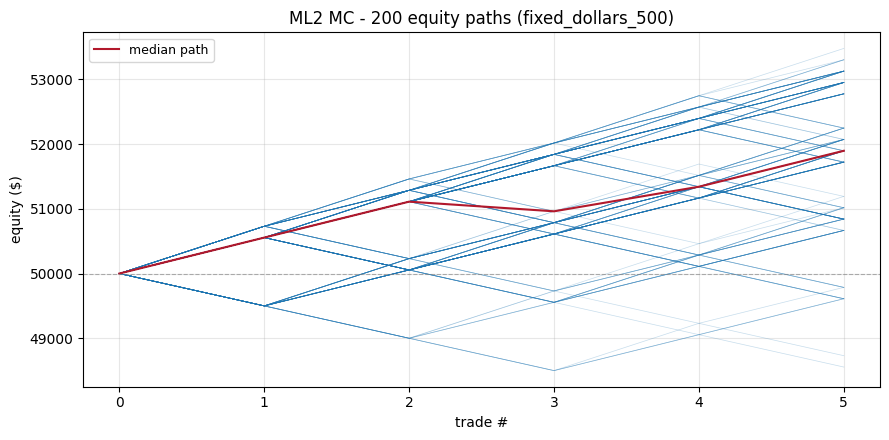

In [3]:
plot_mc_sims(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

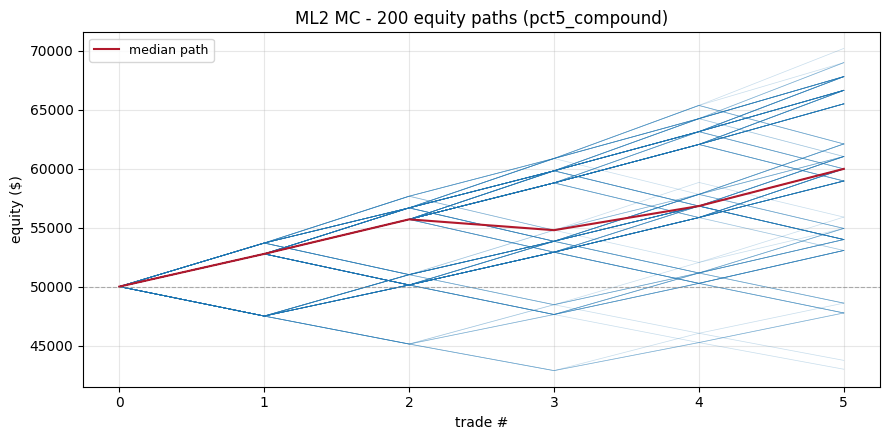

In [4]:
plot_mc_sims(ml2_portfolio['pct5_compound'], 'pct5_compound', 'ML2', YEARS_SPAN)

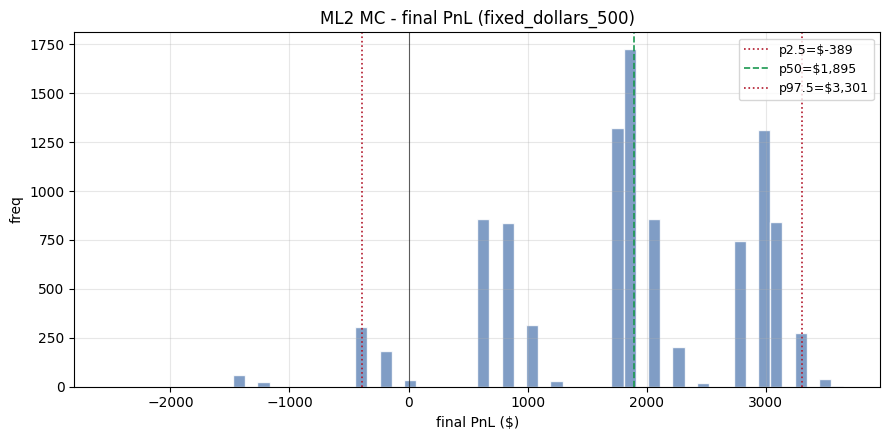

In [5]:
plot_mc_pnl(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

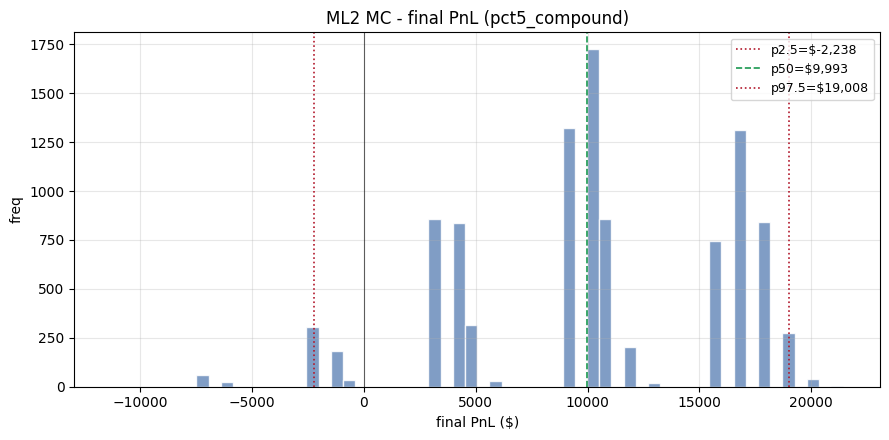

In [6]:
plot_mc_pnl(ml2_portfolio['pct5_compound'], 'pct5_compound', 'ML2', YEARS_SPAN)

/root/intra/scripts/evaluation/_top_perf_common.py:641: RuntimeWarning: divide by zero encountered in divide
  sharpe = np.where(sig > 0, (mu / sig) * np.sqrt(tpy), 0.0)


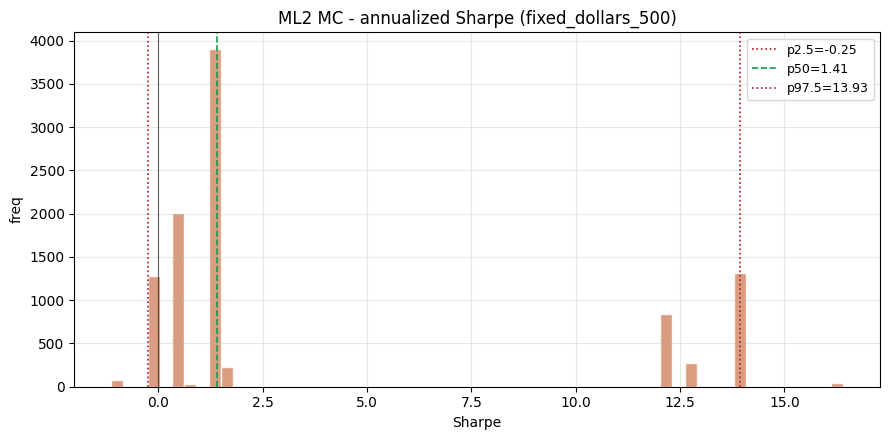

In [7]:
plot_mc_sharpe(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

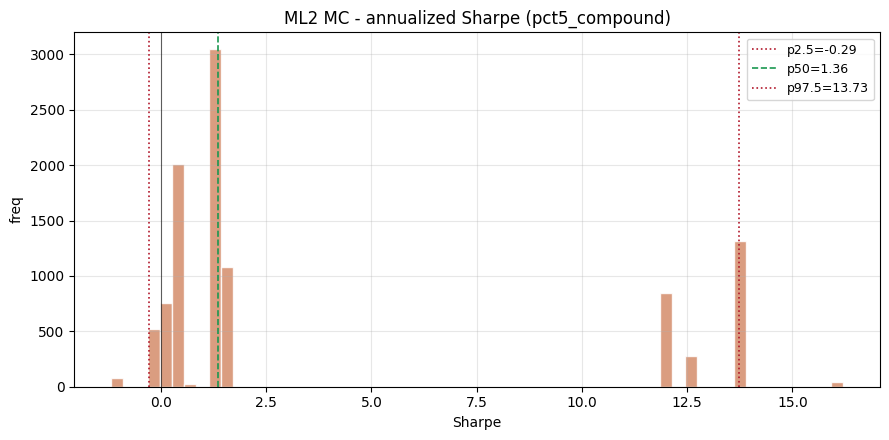

In [8]:
plot_mc_sharpe(ml2_portfolio['pct5_compound'], 'pct5_compound', 'ML2', YEARS_SPAN)

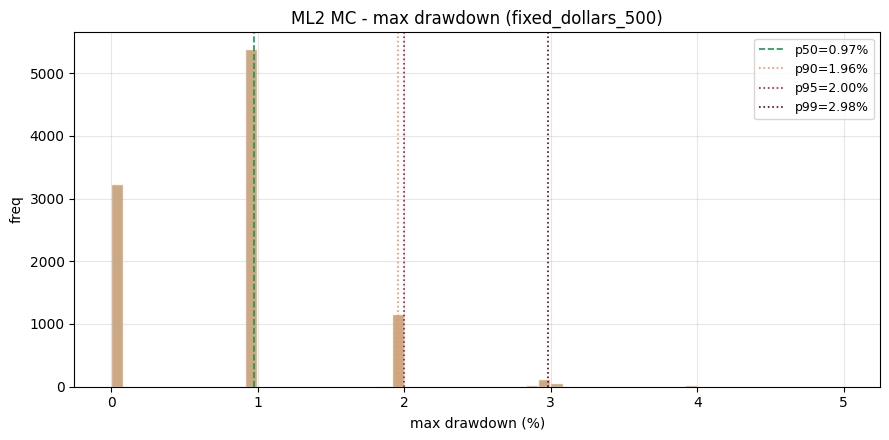

In [9]:
plot_mc_dd(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

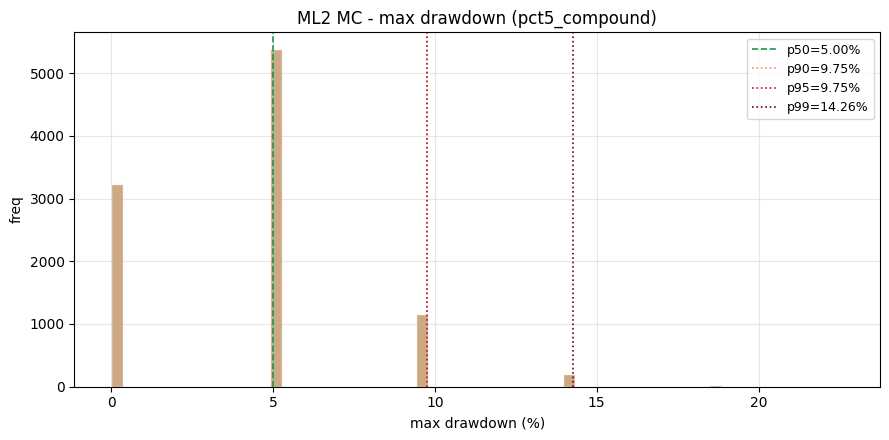

In [10]:
plot_mc_dd(ml2_portfolio['pct5_compound'], 'pct5_compound', 'ML2', YEARS_SPAN)